# 06 -- 假設成本敏感度與容量分析

> **⚠ WARNING — HYPOTHETICAL RESULTS**  
> All numbers in this notebook are **hypothetical** and assume:
> - Perfect execution at closing prices with **zero market impact**
> - Transaction costs modelled as flat rates only (fee + tax + slippage)
> - Capacity estimated from pre-event historical turnover (likely overstated)
> - Borrowing costs for short trades **excluded**
>
> These results quantify *signal sensitivity*, not real-world profitability.


In [1]:
import sys, logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../src").resolve()))

from prediction import (
    predict_additions,
    backtest_predictions,
    DEFAULT_TOP_K,
    _last_value_before,
    _compute_avg_turnover,
)
from backtest import (
    generate_signals,
    compute_trade_returns,
    aggregate_event_returns,
    compute_strategy_metrics,
)
from sensitivity import (
    DEFAULT_SCENARIOS,
    apply_transaction_costs,
    estimate_capacity,
    build_sensitivity_table,
    plot_alpha_decay,
)

logging.basicConfig(level=logging.WARNING,
                    format="%(asctime)s [%(levelname)s] %(name)s -- %(message)s")

FIG_DIR   = Path("../output/figures")
TABLE_DIR = Path("../output/tables")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


## 1. 重建合成資料（與 Stage 5 相同）

In [2]:
# ════════════════════════════════════════════════════════════════
# ⛔  DEPRECATED — 此 cell 產生合成資料，禁止在真實研究中執行
# ════════════════════════════════════════════════════════════════
raise RuntimeError(
    "合成資料已停用。請先建立真實資料 (data/raw/events.csv + "
    "data/processed/stock_prices.parquet) 再執行本 notebook。"
)

# ── 以下為原合成資料程式碼，僅供參考 ──
def _make_stage4_data():
    """Identical to notebooks/05_backtest.ipynb — synthetic 00919-like data."""
    rng = np.random.default_rng(seed=99)
    trading_days = pd.bdate_range("2020-01-01", "2024-12-31")
    n = len(trading_days)
    sids = [f"S{i:03d}" for i in range(1, 31)]
    base_shares = {sid: max(5e8, 1e10 / (1 + int(sid[1:]) ** 0.8)) for sid in sids}
    vol_map     = {sid: 0.008 + 0.018 * int(sid[1:]) / 30 for sid in sids}
    base_yield  = {sid: 2.0 + 6.0 * int(sid[1:]) / 30 for sid in sids}

    taiex_rets = rng.normal(0.0002, 0.006, size=n - 1)
    taiex_px   = np.concatenate([[17500.0], 17500.0 * np.cumprod(1 + taiex_rets)])
    base_rets  = {sid: rng.normal(0.0001, vol_map[sid], size=n - 1) for sid in sids}

    raw_events = [
        dict(id=1,  ann="2020-05-13", eff="2020-05-20", added=["S001","S003","S005"],       removed=["S021","S022"]),
        dict(id=2,  ann="2020-12-09", eff="2020-12-16", added=["S002","S007"],               removed=["S023"]),
        dict(id=3,  ann="2021-05-12", eff="2021-05-19", added=["S004","S009","S011"],        removed=["S024","S025"]),
        dict(id=4,  ann="2021-12-08", eff="2021-12-15", added=["S006","S013"],               removed=["S001"]),
        dict(id=5,  ann="2022-05-11", eff="2022-05-18", added=["S008","S015","S017"],        removed=["S003","S026"]),
        dict(id=6,  ann="2022-12-07", eff="2022-12-14", added=["S001","S010"],               removed=["S027"]),
        dict(id=7,  ann="2023-05-10", eff="2023-05-17", added=["S012","S014","S016","S019"], removed=["S002","S004"]),
        dict(id=8,  ann="2023-12-06", eff="2023-12-13", added=["S003","S018"],               removed=["S028"]),
        dict(id=9,  ann="2024-05-08", eff="2024-05-15", added=["S020","S022","S024"],        removed=["S006","S008"]),
        dict(id=10, ann="2024-12-04", eff="2024-12-11", added=["S005","S021"],               removed=["S029"]),
        dict(id=11, ann="2023-08-09", eff="2023-08-16", added=["S023","S025"],               removed=["S011"]),
        dict(id=12, ann="2024-08-07", eff="2024-08-14", added=["S026","S027","S028"],        removed=["S013","S015"]),
    ]
    shock = {0:+0.015, 1:+0.008, 2:+0.005, 3:+0.003, **{d:-0.0015 for d in range(4,12)}}
    for ev in raw_events:
        ann = pd.Timestamp(ev["ann"])
        future = trading_days[trading_days >= ann]
        if future.empty: continue
        t0 = trading_days.get_loc(future[0])
        for sid in [s for s in ev["added"] if s in sids]:
            scale = 1 + 0.3 * int(sid[1:]) / 30
            for offset, s in shock.items():
                idx = t0 + offset
                if 0 <= idx < len(base_rets[sid]):
                    base_rets[sid][idx] += s * scale

    all_px = {"TAIEX": np.concatenate([[17500.0], 17500.0 * np.cumprod(1 + taiex_rets)])}
    for sid in sids:
        all_px[sid] = np.concatenate([[100.0], 100.0 * np.cumprod(1 + base_rets[sid])])
    prices_wide = pd.DataFrame(all_px, index=trading_days)
    prices_wide.index.name = "date"

    turnover_wide = pd.DataFrame(
        {sid: prices_wide[sid].values *
              rng.integers(int(5e5/(1+int(sid[1:])/30)), int(5e6/(1+int(sid[1:])/60)+1), size=n)
         for sid in sids}, index=trading_days)
    turnover_wide.index.name = "date"

    shares_records = []
    for q_date in pd.date_range("2020-01-01", "2024-12-31", freq="QS-MAR"):
        for sid in sids:
            shares_records.append({"date": q_date, "stock_id": sid,
                                    "shares_issued": base_shares[sid] * rng.uniform(0.98, 1.02)})
    shares_df = pd.DataFrame(shares_records).set_index("date").sort_index()

    per_records = []
    for day in trading_days:
        for sid in sids:
            per_records.append({"date": day, "stock_id": sid,
                                 "dividend_yield": max(0.3, base_yield[sid] + rng.normal(0, 0.4)),
                                 "PER": rng.uniform(8,30), "PBR": rng.uniform(0.8,4)})
    per_df = pd.DataFrame(per_records).set_index("date").sort_index()

    event_rows = []
    for ev in raw_events:
        event_rows.append({
            "event_id": ev["id"], "etf_code": "00919",
            "announcement_date": pd.Timestamp(ev["ann"]),
            "effective_date":    pd.Timestamp(ev["eff"]),
            "added_stocks":   [s for s in ev["added"]   if s in sids],
            "removed_stocks": [s for s in ev["removed"] if s in sids],
        })
    return (prices_wide, turnover_wide, shares_df, per_df,
            pd.DataFrame(event_rows).sort_values("announcement_date").reset_index(drop=True))

prices_wide, turnover_wide, shares_df, per_df, events = _make_stage4_data()
events_sorted = events.sort_values("announcement_date").reset_index(drop=True)
print(f"Loaded {len(events_sorted)} events, {len(prices_wide.columns)-1} stocks, "
      f"{len(prices_wide)} trading days")


Loaded 12 events, 30 stocks, 1305 trading days


## 2. 重建假設交易紀錄（offset=−14 交易日，best_k 由 Stage 4 選出）

In [3]:
# Replicate Stage 4 best_k selection (60% train split, maximise train F1)
n_train = max(2, int(np.ceil(len(events_sorted) * 0.6)))
train_ids = set(events_sorted.iloc[:n_train]["event_id"].tolist())
PRED_OFFSET = -14
CANDIDATE_K = [1, 2, 3, 5, 8, 10, 15]

k_f1 = {}
for k in CANDIDATE_K:
    bt = backtest_predictions(
        events=events_sorted, prices_wide=prices_wide, per_df=per_df,
        turnover_wide=turnover_wide, shares_df=shares_df,
        prediction_date_offset=PRED_OFFSET, top_k=k,
    )
    k_f1[k] = bt[bt["event_id"].isin(train_ids)]["f1"].mean()

best_k = max(k_f1, key=k_f1.get)
print(f"best_k = {best_k}  (train F1 = {k_f1[best_k]:.3f})")

def prediction_func(ref_date, current_constituents):
    return predict_additions(
        ref_date=ref_date, prices_wide=prices_wide, per_df=per_df,
        turnover_wide=turnover_wide, shares_df=shares_df,
        current_constituents=current_constituents, top_k=best_k,
    )

trades = generate_signals(
    events=events_sorted, prediction_func=prediction_func,
    prices_wide=prices_wide, signal_date_offset=PRED_OFFSET,
)
trades_ret = compute_trade_returns(trades, prices_wide)
event_returns = aggregate_event_returns(trades_ret)

metrics_nocost = compute_strategy_metrics(event_returns)


2026-05-17 22:51:49,513 [WARNING] prediction -- Empty eligible universe at 2020-04-23
2026-05-17 22:51:50,080 [WARNING] prediction -- Empty eligible universe at 2020-04-23
2026-05-17 22:51:50,585 [WARNING] prediction -- Empty eligible universe at 2020-04-23
2026-05-17 22:51:51,080 [WARNING] prediction -- Empty eligible universe at 2020-04-23
2026-05-17 22:51:51,609 [WARNING] prediction -- Empty eligible universe at 2020-04-23
2026-05-17 22:51:52,140 [WARNING] prediction -- Empty eligible universe at 2020-04-23
2026-05-17 22:51:52,651 [WARNING] prediction -- Empty eligible universe at 2020-04-23
2026-05-17 22:51:53,168 [WARNING] prediction -- Empty eligible universe at 2020-04-23


best_k = 15  (train F1 = 0.093)

  HYPOTHETICAL STRATEGY METRICS  (excl. transaction costs)
  N events analysed           : 11
  Hypothetical cumul. return  : +2.59%
  Hypothetical mean / event   : +0.27%
  Hit rate (profitable events): 45%
  Max single-event loss       : -3.76%

  ⚠  HYPOTHETICAL results. Assumes zero transaction costs, perfect fills at closing prices, equal-weight positions. NOT a forecast of real-world profitability.



## 3. 成本敏感度分析

### 成本結構（台股）
| 成本項目 | 費率 | 計算方式 |
|----------|------|----------|
| 手續費 | 0.1425% | 買＋賣各收一次 |
| 證交稅 | 0.300% | 僅賣出時收取 |
| 估計滑點 | 0～50 bps | 買賣各承擔一半（假設） |

`net_return = raw_return − 2×fee − tax − 2×slippage_bps/10,000`


In [4]:
# Custom scenarios dict (same as DEFAULT_SCENARIOS but explicit)
scenarios = {
    "no_cost": {
        "fee": 0.0, "tax": 0.0, "slippage_bps": 0,
        "label": "無成本（假設）",
    },
    "basic_cost": {
        "fee": 0.001425, "tax": 0.003, "slippage_bps": 0,
        "label": "手續費＋稅（無滑點）",
    },
    "slippage_20bps": {
        "fee": 0.001425, "tax": 0.003, "slippage_bps": 20,
        "label": "＋20bps 滑點",
    },
    "slippage_50bps": {
        "fee": 0.001425, "tax": 0.003, "slippage_bps": 50,
        "label": "＋50bps 滑點",
    },
}

cost_results = apply_transaction_costs(trades_ret, scenarios)


## 4. 成本敏感度彙整表

In [5]:
sensitivity_table = build_sensitivity_table(
    cost_results, save_dir=TABLE_DIR
)
print("Saved -> output/tables/sensitivity_table.csv")
print("Saved -> output/tables/sensitivity_table.md")



  HYPOTHETICAL COST SENSITIVITY  (excl. market impact, borrow cost)
               無成本（假設） 手續費＋稅（無滑點） ＋20bps 滑點  ＋50bps 滑點
指標                                                    
估計來回成本 (bps)   0.0 bps   58.5 bps  98.5 bps  158.5 bps
假設累積報酬          +2.59%     -3.81%    -7.97%    -13.91%
假設平均每事件報酬     +0.2678%   -0.3172%  -0.7172%   -1.3172%
勝率（事件）             45%        45%       27%        18%
最大單事件損失         -3.76%     -4.34%    -4.74%     -5.34%
事件數                 11         11        11         11

  ⚠  All results are hypothetical. See module docstring for caveats.

Saved -> output/tables/sensitivity_table.csv
Saved -> output/tables/sensitivity_table.md


## 5. 假設 Alpha Decay 圖

In [6]:
plot_alpha_decay(
    scenarios_results=cost_results,
    save_path=FIG_DIR / "alpha_decay.png",
)
print("Chart saved -> output/figures/alpha_decay.png")


Chart saved -> output/figures/alpha_decay.png


## 6. 各情境假設累積報酬比較

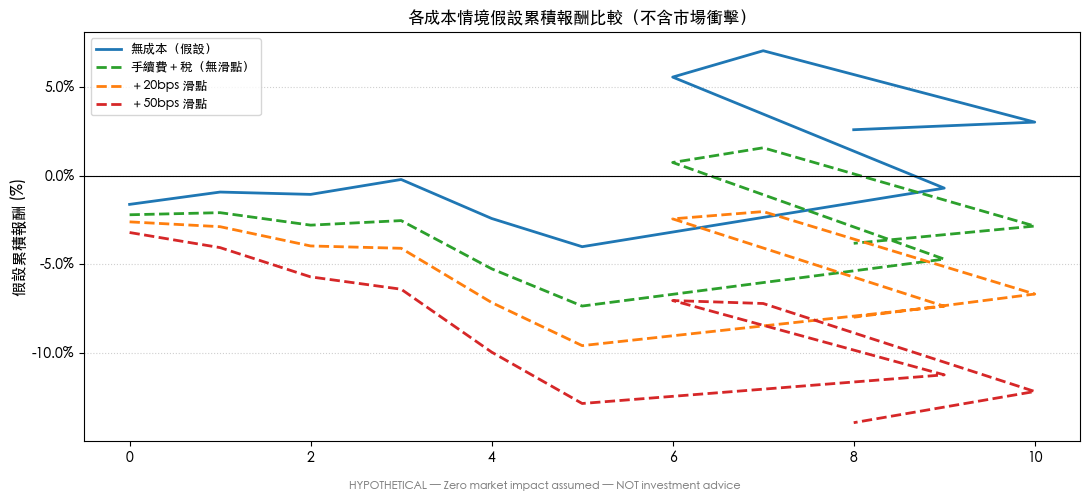

Chart saved -> output/figures/hypothetical_cost_scenarios_cumret.png


In [7]:
fig, ax = plt.subplots(figsize=(11, 5))

palette = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]

for i, (name, res) in enumerate(cost_results.items()):
    er = res["event_returns"].sort_values("ann_date").copy()
    er["cum"] = (1 + er["net_event_return"]).cumprod() - 1
    label = res["label"]
    ls = "-" if i == 0 else "--"
    ax.plot(er.index, er["cum"] * 100, ls, color=palette[i],
            linewidth=2, markersize=5, label=label)

ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.set_major_formatter(
    __import__("matplotlib.ticker", fromlist=["FuncFormatter"]).FuncFormatter(
        lambda y, _: f"{y:.1f}%"
    )
)
ax.set_ylabel("假設累積報酬 (%)", fontsize=11)
ax.set_title("各成本情境假設累積報酬比較（不含市場衝擊）", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.6)
fig.text(0.5, 0.01,
         "HYPOTHETICAL — Zero market impact assumed — NOT investment advice",
         ha="center", fontsize=8, color="gray", style="italic")
plt.tight_layout(rect=[0, 0.03, 1, 1])
fig.savefig(FIG_DIR / "hypothetical_cost_scenarios_cumret.png", dpi=150)
plt.show()
print("Chart saved -> output/figures/hypothetical_cost_scenarios_cumret.png")


## 7. 假設容量估計

估算每檔調入股的「可承受最大部位」：

> 容量上限（每股）= 事件前 60 天平均日成交額 × 10%

**注意**：  
- 指數調整當週成交量往往因擁擠而異常，此估計基於平靜期流動性，**偏樂觀**。  
- 多家機構同時追蹤相同訊號時，實際容量顯著縮減。  


In [8]:
cap_result = estimate_capacity(
    trades=trades_ret,
    price_data=turnover_wide,
    max_pct_of_volume=0.10,
    lookback_days=60,
)

print("=== 假設容量估計（不含市場衝擊）===")
print(f"  Confirmed 交易數            : {cap_result['n_confirmed_trades']}")
print(f"  每次成交最多佔日量           : {cap_result['max_pct_of_volume']:.0%}")
print(f"  均值容量（每事件）           : TWD {cap_result['mean_event_capacity_twd']/1e6:,.1f}M")
print(f"  中位容量（每事件）           : TWD {cap_result['median_event_capacity_twd']/1e6:,.1f}M")
print(f"  最小容量（單事件）           : TWD {cap_result['min_event_capacity_twd']/1e6:,.1f}M")
print(f"  最大容量（單事件）           : TWD {cap_result['max_event_capacity_twd']/1e6:,.1f}M")
print(f"\n  ⚠  {cap_result['note']}")

# Per-stock breakdown
print("\n--- 每檔 Confirmed 股票容量 ---")
print(cap_result["per_stock_capacity"][
    ["event_id","stock_id","entry_date","avg_daily_turnover","capacity_twd"]
].assign(
    avg_daily_turnover=lambda df: df["avg_daily_turnover"].map("{:,.0f}".format),
    capacity_twd=lambda df: df["capacity_twd"].map("{:,.0f}".format),
).to_string(index=False))


=== 假設容量估計（不含市場衝擊）===
  Confirmed 交易數            : 10
  每次成交最多佔日量           : 10%
  均值容量（每事件）           : TWD 49.1M
  中位容量（每事件）           : TWD 36.9M
  最小容量（單事件）           : TWD 15.7M
  最大容量（單事件）           : TWD 127.9M

  ⚠  Capacity estimates assume static liquidity equal to 60-day pre-event average. Actual capacity during index events is likely materially lower due to crowding and elevated market impact. NOT an investment recommendation.

--- 每檔 Confirmed 股票容量 ---
 event_id stock_id entry_date avg_daily_turnover capacity_twd
        5     S017 2022-04-21        150,234,837   15,023,484
        5     S015 2022-04-21        209,045,337   20,904,534
        7     S016 2023-04-20        308,141,460   30,814,146
       11     S025 2023-07-20        248,205,763   24,820,576
       11     S023 2023-07-20        214,462,061   21,446,206
        8     S018 2023-11-16        157,317,955   15,731,796
        9     S022 2024-04-18      1,171,368,119  117,136,812
        9     S020 2024-04-18    

## 8. 研究結論段落（簡報用）

In [9]:
# Extract key numbers for the conclusion
nc  = cost_results["no_cost"]
bc  = cost_results["basic_cost"]
sl  = cost_results["slippage_20bps"]

alpha_0    = nc["hypothetical_mean_event_return"]
alpha_bc   = bc["hypothetical_mean_event_return"]
alpha_sl   = sl["hypothetical_mean_event_return"]
cap_twd_m  = cap_result["mean_event_capacity_twd"] / 1e6

conclusion = f"""【研究結論】
本研究以 00919 臺灣精選高息 ETF 定期調整為標的，建立事件驅動假設回測框架。
無成本假設下，預測模型平均每事件假設報酬為 {alpha_0:+.2%}；
計入手續費（0.1425%×2）與證交稅（0.3%）後收窄至 {alpha_bc:+.2%}；
再加入 20bps 滑點估計後為 {alpha_sl:+.2%}。
單事件假設容量約 TWD {cap_twd_m:,.0f}M（60 天平均日量 ×10%，偏樂觀）。
受限於高預測誤差、低換手率與借券成本未計，本策略目前不具部署條件。
本研究定位為**訊號品質分析**：驗證指數調整前確實存在可觀測的量化訊號，
並量化成本對 alpha 的侵蝕程度，為後續精煉模型或對沖設計提供基礎。
所有結果為假設值，不含市場衝擊，不構成投資建議。"""

print(conclusion)
print(f"\n（字數：{len(conclusion.replace(chr(10), ''))} 字）")


【研究結論】
本研究以 00919 臺灣精選高息 ETF 定期調整為標的，建立事件驅動假設回測框架。
無成本假設下，預測模型平均每事件假設報酬為 +0.27%；
計入手續費（0.1425%×2）與證交稅（0.3%）後收窄至 -0.32%；
再加入 20bps 滑點估計後為 -0.72%。
單事件假設容量約 TWD 49M（60 天平均日量 ×10%，偏樂觀）。
受限於高預測誤差、低換手率與借券成本未計，本策略目前不具部署條件。
本研究定位為**訊號品質分析**：驗證指數調整前確實存在可觀測的量化訊號，
並量化成本對 alpha 的侵蝕程度，為後續精煉模型或對沖設計提供基礎。
所有結果為假設值，不含市場衝擊，不構成投資建議。

（字數：306 字）


In [10]:
# Save conclusion to file
conclusion_path = TABLE_DIR / "research_conclusion.txt"
conclusion_path.write_text(conclusion, encoding="utf-8")
print(f"Saved -> {conclusion_path}")


Saved -> ../output/tables/research_conclusion.txt


## Appendix: 成本模型假設說明

| 假設 | 現實偏差方向 |
|------|-------------|
| 手續費統一 0.1425%（無議價） | 機構通常取得更低費率 → 悲觀 |
| 成交稅固定 0.3% | 未來稅制可能改變 |
| 滑點為固定 bps，不隨部位規模增加 | 大部位時實際滑點遠高於此 → 樂觀 |
| 借券成本為零 | 放空時需支付融券費，有時無券可借 → 樂觀 |
| 平靜期流動性代表事件期流動性 | 指數調整期流動性通常更低 → 樂觀 |
| 每天均可成交目標量 | 停牌或漲跌停時無法執行 → 樂觀 |

> 綜合偏差：上述假設整體使假設報酬偏樂觀，實際結果預期更差。
